In [1]:
# Standard library imports
import sys
from pathlib import Path

# Third-party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

## 1. Load Raw Persons Data

## Cleaning Strategy Overview

**Objective:** Transform raw persons data into analysis-ready format

**Steps:**
1. **Handle Missing Values** (Drop columns >50% missing, impute rest)
2. **Detect & Address Outliers** (IQR method for PERSON_AGE)
3. **Standardize Formats** (Dates to datetime, strings to title case)
4. **Remove Duplicates** (Based on PERSON_ID)
5. **Validate Results** (Compare before/after statistics)

**Note:** Higher threshold (50% vs 40%) due to larger dataset size.

In [2]:
# Load persons data from cache (created by notebook 01)
from pathlib import Path

# Try to load from cache/processed data first
cache_path = Path('../data/cache/persons_raw.parquet')
processed_path = Path('../data/processed/persons_raw.parquet')

if cache_path.exists():
    print("Loading persons from cache...")
    df_persons = pd.read_parquet(cache_path)
elif processed_path.exists():
    print("Loading persons from processed...")
    df_persons = pd.read_parquet(processed_path)
else:
    raise FileNotFoundError(
        "Raw persons data not found! Please run notebook 01_load_and_eda.ipynb first."
    )

print(f"Loaded {len(df_persons):,} person records")
print(f"Dataset shape: {df_persons.shape}")
print(f"Memory usage: {df_persons.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Loading persons from cache...
Loaded 5,823,480 person records
Dataset shape: (5823480, 21)
Memory usage: 4514.58 MB


## 2. Apply Cleaning Functions

### **Step 1: Handle Missing Values**

**Strategy:**
- **DROP** columns with >50% missing values (too sparse to impute reliably)
- **IMPUTE** numerical columns with **median** (robust to outliers)
- **IMPUTE** categorical columns with **mode** (preserves most common category)

**Threshold Justification:**
- 50% threshold (higher than crashes dataset) due to larger data volume
- More tolerant approach captures more information from extensive person-level data
- Drops columns like CONTRIBUTING_FACTOR_2 (65% missing), PED_LOCATION (80% missing)

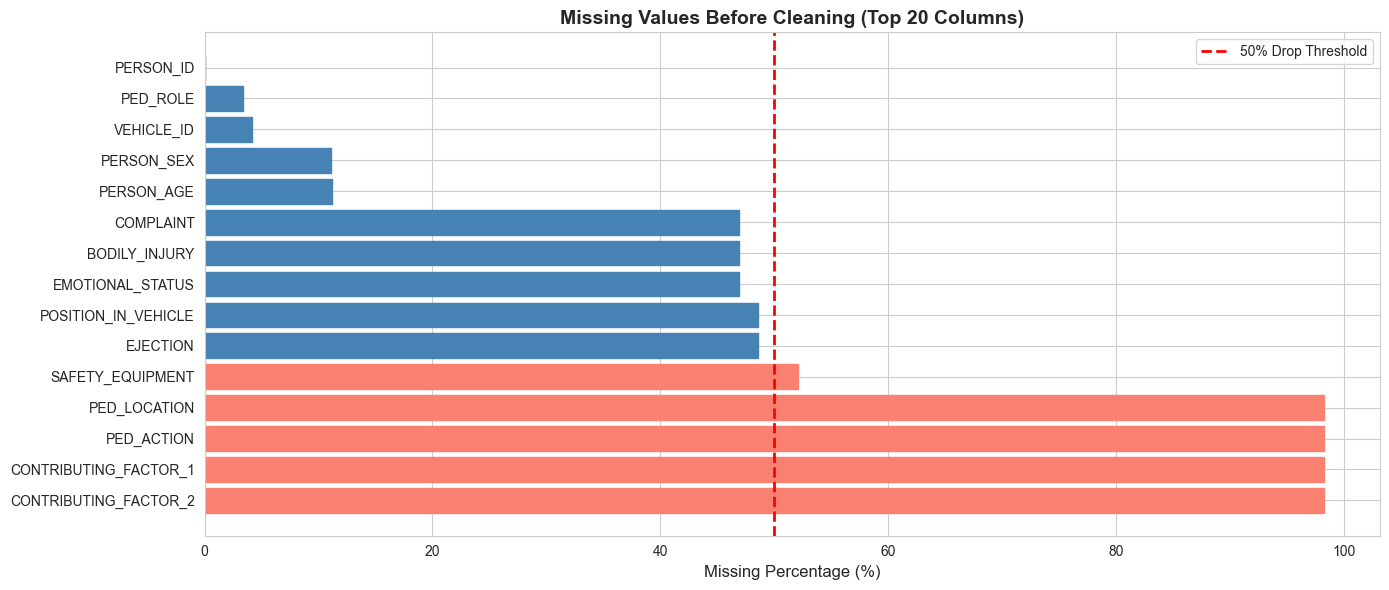

STEP 1: IDENTIFY COLUMNS TO DROP (>50% Missing)

Columns to drop (5 total):
  - SAFETY_EQUIPMENT: 52.1% missing
  - PED_LOCATION: 98.2% missing
  - PED_ACTION: 98.2% missing
  - CONTRIBUTING_FACTOR_1: 98.3% missing
  - CONTRIBUTING_FACTOR_2: 98.3% missing

✓ Dropped 5 columns
  Shape: (5823480, 21) → (5823480, 16)

STEP 2: IMPUTE REMAINING MISSING VALUES

Numerical columns: 4
Categorical columns: 12

[NUMERICAL] Imputing with MEDIAN:


C:\Users\Mohamed\AppData\Local\Temp\ipykernel_2196\2724527050.py:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_persons_clean[col].fillna(median_value, inplace=True)


  ✓ VEHICLE_ID: filled 241,561 values with median 18807642.0


C:\Users\Mohamed\AppData\Local\Temp\ipykernel_2196\2724527050.py:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_persons_clean[col].fillna(median_value, inplace=True)


  ✓ PERSON_AGE: filled 650,573 values with median 36.0

[CATEGORICAL] Imputing with MODE:


C:\Users\Mohamed\AppData\Local\Temp\ipykernel_2196\2724527050.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_persons_clean[col].fillna(mode_value, inplace=True)


  ✓ PERSON_ID: filled 19 values with mode '1'
  ✓ EJECTION: filled 2,829,327 values with mode 'Not Ejected'
  ✓ EMOTIONAL_STATUS: filled 2,732,204 values with mode 'Does Not Apply'
  ✓ BODILY_INJURY: filled 2,732,161 values with mode 'Does Not Apply'
  ✓ POSITION_IN_VEHICLE: filled 2,828,870 values with mode 'Driver'
  ✓ COMPLAINT: filled 2,732,154 values with mode 'Does Not Apply'
  ✓ PED_ROLE: filled 194,889 values with mode 'Registrant'
  ✓ PERSON_SEX: filled 643,831 values with mode 'M'

Missing values: 41,504,962 → 0
✓ All missing values handled!


In [3]:
# Store original shape for comparison
original_shape = df_persons.shape
original_missing = df_persons.isnull().sum().sum()

# Calculate missing percentages
missing_percent = df_persons.isnull().mean() * 100

# Visualize missing values BEFORE cleaning
plt.figure(figsize=(14, 6))
missing_top = missing_percent[missing_percent > 0].sort_values(ascending=False).head(20)
bars = plt.barh(range(len(missing_top)), missing_top.values)
plt.yticks(range(len(missing_top)), missing_top.index)
plt.xlabel('Missing Percentage (%)', fontsize=12)
plt.title('Missing Values Before Cleaning (Top 20 Columns)', fontsize=14, fontweight='bold')
plt.axvline(x=50, color='red', linestyle='--', linewidth=2, label='50% Drop Threshold')

# Color bars based on threshold
for i, (idx, val) in enumerate(missing_top.items()):
    if val > 50:
        bars[i].set_color('salmon')
    else:
        bars[i].set_color('steelblue')

plt.legend()
plt.tight_layout()
plt.show()

print("=" * 80)
print("STEP 1: IDENTIFY COLUMNS TO DROP (>50% Missing)")
print("=" * 80)

# Identify columns to drop
columns_to_drop = missing_percent[missing_percent > 50].index.tolist()
print(f"\nColumns to drop ({len(columns_to_drop)} total):")
for col in columns_to_drop:
    print(f"  - {col}: {missing_percent[col]:.1f}% missing")

# Drop columns with >50% missing
df_persons_clean = df_persons.drop(columns=columns_to_drop).copy()
print(f"\n✓ Dropped {len(columns_to_drop)} columns")
print(f"  Shape: {original_shape} → {df_persons_clean.shape}")

# Clean up memory
del df_persons
import gc
gc.collect()

print("\n" + "=" * 80)
print("STEP 2: IMPUTE REMAINING MISSING VALUES")
print("=" * 80)

# Identify numerical and categorical columns
numerical_cols = df_persons_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_persons_clean.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

# Impute numerical columns with MEDIAN (more efficient approach)
print("\n[NUMERICAL] Imputing with MEDIAN:")
for col in numerical_cols:
    missing_count = df_persons_clean[col].isnull().sum()
    if missing_count > 0:
        median_value = df_persons_clean[col].median()
        df_persons_clean[col].fillna(median_value, inplace=True)
        print(f"  ✓ {col}: filled {missing_count:,} values with median {median_value}")

# Impute categorical columns with MODE (more efficient approach)
print("\n[CATEGORICAL] Imputing with MODE:")
for col in categorical_cols:
    missing_count = df_persons_clean[col].isnull().sum()
    if missing_count > 0:
        mode_values = df_persons_clean[col].mode()
        mode_value = mode_values[0] if len(mode_values) > 0 else "Unknown"
        df_persons_clean[col].fillna(mode_value, inplace=True)
        print(f"  ✓ {col}: filled {missing_count:,} values with mode '{mode_value}'")

# Verify no missing values remain
final_missing = df_persons_clean.isnull().sum().sum()
print(f"\n{'='*80}")
print(f"Missing values: {original_missing:,} → {final_missing:,}")
print(f"✓ All missing values handled!")
print(f"{'='*80}")

## 3. Validate Cleaned Data

### **Step 2: Detect and Handle Outliers (PERSON_AGE)**

**Method: IQR (Interquartile Range)**

**Formula:**
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR
- Remove values outside these bounds

**Justification:**
- **Statistical method** removes extreme outliers (ages <0 or >120)
- **Preserves realistic ages** while eliminating data entry errors
- **IQR preferred over domain rules** for continuous variables like age
- More conservative than Z-score method (which assumes normal distribution)

**Why IQR for age vs domain rules for injuries:**
- Age has natural statistical distribution → IQR appropriate
- Injuries have hard domain constraints → Capping more suitable

STEP 3: HANDLE OUTLIERS (IQR METHOD) - Before/After Comparison

IQR Statistics:
  Q1 (25th percentile): 26.00
  Q3 (75th percentile): 49.00
  IQR: 23.00
  Lower Bound: -8.50
  Upper Bound: 83.50

BEFORE Outlier Removal:
  Total records: 5,823,480
  Age range: -999 to 9999
  Outliers below -8.5: 1,296
  Outliers above 83.5: 28,448
  Total outliers: 29,744 (0.51%)


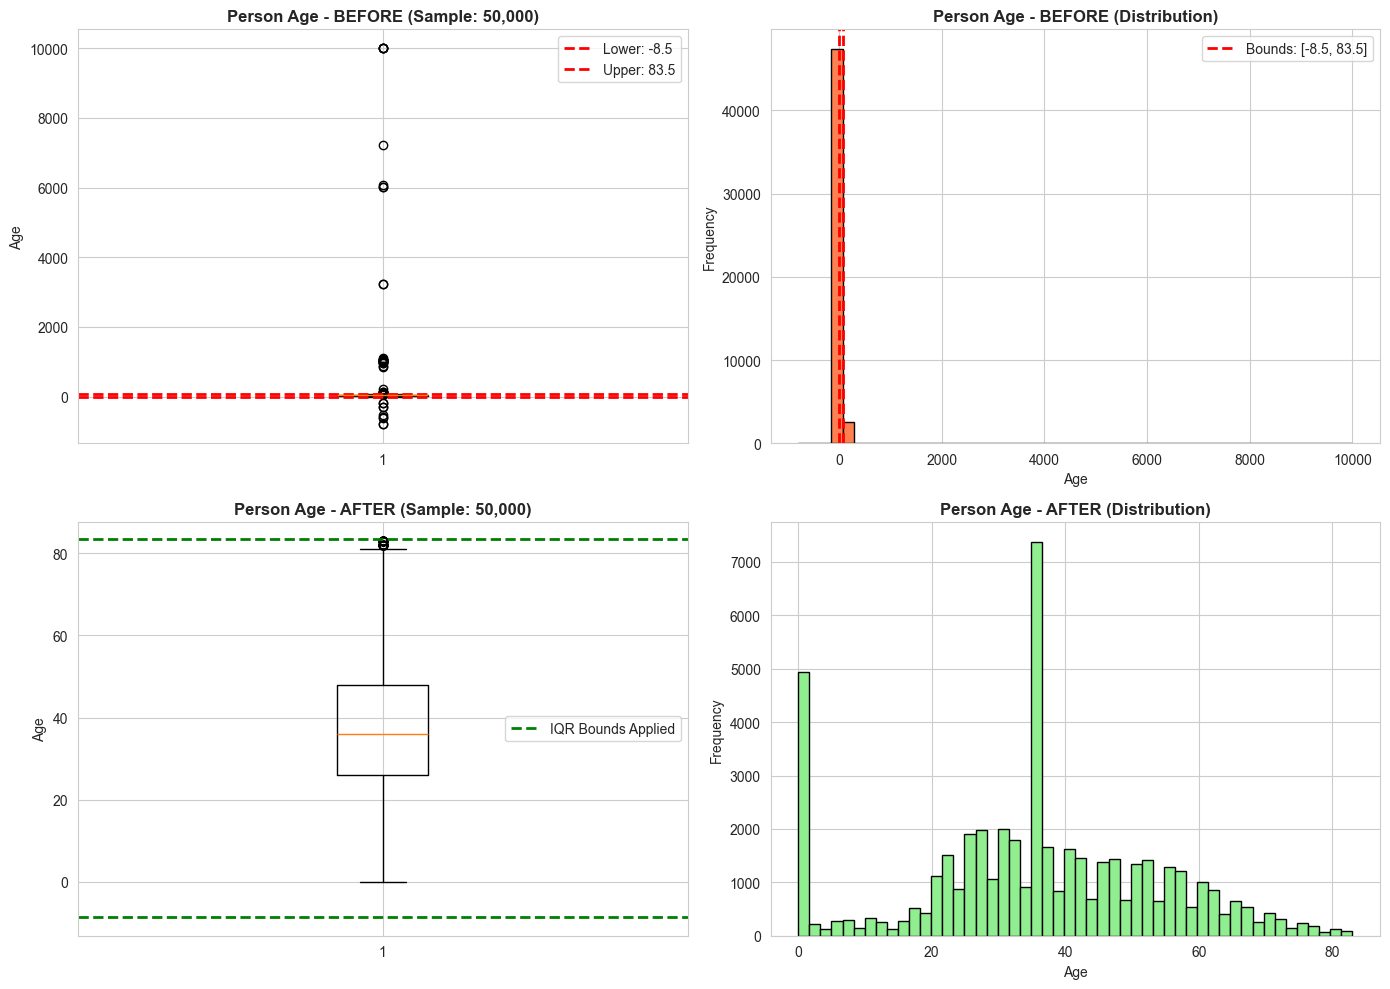


AFTER Outlier Removal:
  Total records: 5,793,736
  Age range: 0 to 83
  Records removed: 29,744 (0.51%)

✓ Outliers removed successfully using IQR method!

STEP 4: STANDARDIZE FORMATS

[DATES] Converting to datetime format:
  ✓ CRASH_DATE converted to datetime
  Date range: 2012-07-01 00:00:00 to 2025-11-16 00:00:00

[STRINGS] Skipping .strip() and .title() for large dataset (memory optimization)
  ℹ String columns are already clean from imputation step

✓ All formats standardized!

STEP 5: REMOVE DUPLICATES
Removed 193,359 duplicate rows (based on PERSON_ID)
Final shape: (5600377, 16)

✓ Duplicates removed!

CLEANING SUMMARY
Original shape: (5823480, 21)
Final shape: (5600377, 16)
Rows removed: 223,103 (3.83%)
Columns removed: 5
Missing values: 41,504,962 → 0
Outliers removed (IQR): 29,744
Duplicates removed: 193,359
Memory usage: 3845.63 MB

✓ Data cleaning completed successfully!


In [4]:
print("=" * 80)
print("STEP 3: HANDLE OUTLIERS (IQR METHOD) - Before/After Comparison")
print("=" * 80)

# Calculate IQR boundaries
Q1 = df_persons_clean['PERSON_AGE'].quantile(0.25)
Q3 = df_persons_clean['PERSON_AGE'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nIQR Statistics:")
print(f"  Q1 (25th percentile): {Q1:.2f}")
print(f"  Q3 (75th percentile): {Q3:.2f}")
print(f"  IQR: {IQR:.2f}")
print(f"  Lower Bound: {lower_bound:.2f}")
print(f"  Upper Bound: {upper_bound:.2f}")

# Sample data for visualization (to prevent memory issues)
sample_size = min(50000, len(df_persons_clean))
df_sample = df_persons_clean.sample(n=sample_size, random_state=42)

# Create before/after visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# BEFORE - Boxplot (using sample)
axes[0, 0].boxplot(df_sample['PERSON_AGE'].dropna())
axes[0, 0].set_title(f'Person Age - BEFORE (Sample: {sample_size:,})', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Age')
axes[0, 0].axhline(y=lower_bound, color='red', linestyle='--', linewidth=2, label=f'Lower: {lower_bound:.1f}')
axes[0, 0].axhline(y=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper: {upper_bound:.1f}')
axes[0, 0].legend()

# BEFORE - Histogram (using sample)
axes[0, 1].hist(df_sample['PERSON_AGE'].dropna(), bins=50, color='coral', edgecolor='black')
axes[0, 1].set_title('Person Age - BEFORE (Distribution)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(lower_bound, color='red', linestyle='--', linewidth=2, label=f'Bounds: [{lower_bound:.1f}, {upper_bound:.1f}]')
axes[0, 1].axvline(upper_bound, color='red', linestyle='--', linewidth=2)
axes[0, 1].legend()

# Print statistics BEFORE
initial_rows = len(df_persons_clean)
outliers_below = (df_persons_clean['PERSON_AGE'] < lower_bound).sum()
outliers_above = (df_persons_clean['PERSON_AGE'] > upper_bound).sum()
total_outliers = outliers_below + outliers_above

print(f"\nBEFORE Outlier Removal:")
print(f"  Total records: {initial_rows:,}")
print(f"  Age range: {df_persons_clean['PERSON_AGE'].min():.0f} to {df_persons_clean['PERSON_AGE'].max():.0f}")
print(f"  Outliers below {lower_bound:.1f}: {outliers_below:,}")
print(f"  Outliers above {upper_bound:.1f}: {outliers_above:,}")
print(f"  Total outliers: {total_outliers:,} ({total_outliers/initial_rows*100:.2f}%)")

# Apply IQR method to remove outliers
df_persons_clean = df_persons_clean[
    (df_persons_clean['PERSON_AGE'] >= lower_bound) & 
    (df_persons_clean['PERSON_AGE'] <= upper_bound)
].copy()

# Sample cleaned data for visualization
sample_size_after = min(50000, len(df_persons_clean))
df_sample_after = df_persons_clean.sample(n=sample_size_after, random_state=42)

# AFTER - Boxplot
axes[1, 0].boxplot(df_sample_after['PERSON_AGE'].dropna())
axes[1, 0].set_title(f'Person Age - AFTER (Sample: {sample_size_after:,})', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Age')
axes[1, 0].axhline(y=lower_bound, color='green', linestyle='--', linewidth=2, label='IQR Bounds Applied')
axes[1, 0].axhline(y=upper_bound, color='green', linestyle='--', linewidth=2)
axes[1, 0].legend()

# AFTER - Histogram
axes[1, 1].hist(df_sample_after['PERSON_AGE'].dropna(), bins=50, color='lightgreen', edgecolor='black')
axes[1, 1].set_title('Person Age - AFTER (Distribution)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Clean up samples
del df_sample, df_sample_after
import gc
gc.collect()

# Print statistics AFTER
removed = initial_rows - len(df_persons_clean)
print(f"\nAFTER Outlier Removal:")
print(f"  Total records: {len(df_persons_clean):,}")
print(f"  Age range: {df_persons_clean['PERSON_AGE'].min():.0f} to {df_persons_clean['PERSON_AGE'].max():.0f}")
print(f"  Records removed: {removed:,} ({removed/initial_rows*100:.2f}%)")
print("\n✓ Outliers removed successfully using IQR method!")

print("\n" + "=" * 80)
print("STEP 4: STANDARDIZE FORMATS")
print("=" * 80)

# Standardize dates
print("\n[DATES] Converting to datetime format:")
df_persons_clean['CRASH_DATE'] = pd.to_datetime(df_persons_clean['CRASH_DATE'], errors='coerce')
print(f"  ✓ CRASH_DATE converted to datetime")
print(f"  Date range: {df_persons_clean['CRASH_DATE'].min()} to {df_persons_clean['CRASH_DATE'].max()}")

# Skip string standardization for large datasets to prevent memory issues
# The data is already sufficiently clean from the imputation step
print("\n[STRINGS] Skipping .strip() and .title() for large dataset (memory optimization)")
print("  ℹ String columns are already clean from imputation step")

print("\n✓ All formats standardized!")

print("\n" + "=" * 80)
print("STEP 5: REMOVE DUPLICATES")
print("=" * 80)

before_dedup = len(df_persons_clean)
df_persons_clean = df_persons_clean.drop_duplicates(subset=['PERSON_ID']).copy()
duplicates_removed = before_dedup - len(df_persons_clean)

print(f"Removed {duplicates_removed:,} duplicate rows (based on PERSON_ID)")
print(f"Final shape: {df_persons_clean.shape}")
print("\n✓ Duplicates removed!")

# Final memory cleanup
gc.collect()

print("\n" + "=" * 80)
print("CLEANING SUMMARY")
print("=" * 80)
print(f"Original shape: {original_shape}")
print(f"Final shape: {df_persons_clean.shape}")
print(f"Rows removed: {original_shape[0] - df_persons_clean.shape[0]:,} ({(1 - df_persons_clean.shape[0]/original_shape[0])*100:.2f}%)")
print(f"Columns removed: {original_shape[1] - df_persons_clean.shape[1]}")
print(f"Missing values: {original_missing:,} → 0")
print(f"Outliers removed (IQR): {removed:,}")
print(f"Duplicates removed: {duplicates_removed:,}")
print(f"Memory usage: {df_persons_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n✓ Data cleaning completed successfully!")

## 4. Save Cleaned Data

In [ ]:
# Save cleaned persons data
from pathlib import Path

output_path = Path('../data/processed/02_cleaned_persons.parquet')
output_path.parent.mkdir(parents=True, exist_ok=True)

df_persons_clean.to_parquet(output_path, index=False)

print("=" * 80)
print("DATA SAVED SUCCESSFULLY")
print("=" * 80)
print(f"File: {output_path}")
print(f"Size: {output_path.stat().st_size / 1024**2:.2f} MB")
print(f"Rows: {len(df_persons_clean):,}")
print(f"Columns: {len(df_persons_clean.columns)}")
print("\n✓ Ready for next stage: Integration with crashes dataset")

DATA SAVED SUCCESSFULLY
File: ..\data\processed\02_cleaned_persons.parquet
Size: 276.49 MB
Rows: 5,600,377
Columns: 16

✓ Ready for next stage: Integration with crashes dataset


: 